In [1]:
## Defining the known values 

import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

## Determined with similar triangles 
Beta_1 = np.pi/2
Beta_2 = np.deg2rad(210)
Beta_3 = np.deg2rad(330)

## Knowns given in question 
u1 = -2 
u2 = 1
u3 = 1

l = 25/100 ## convert to m 
r = 10/100 ## convert to m

x1 = l
y1 = 0 

x2 = l*np.sin(Beta_2)  ## NEED TO CONFIRM THESE DIRECTIONS, when you plug in value gives negative x which makes sense 
y2 = -l*np.cos(Beta_2) ## don't think this is beta 

x3 = l*np.sin(Beta_3)
y3 = -l*np.cos(Beta_3)

In [2]:
# Write the matrix 

def construct_matrix(theta):
    A = np.array([
        [np.cos(theta + Beta_1), np.sin(theta + Beta_1),
         x1 * np.sin(Beta_1) - y1 * np.cos(Beta_1)],
        [np.cos(theta + Beta_2), np.sin(theta + Beta_2),
         x2 * np.sin(Beta_2) - y2 * np.cos(Beta_2)],
        [np.cos(theta + Beta_3), np.sin(theta + Beta_3),
         x3 * np.sin(Beta_3) - y3 * np.cos(Beta_3)]
    ])
    A = 1/r * A
    return A

[-2  1  1]


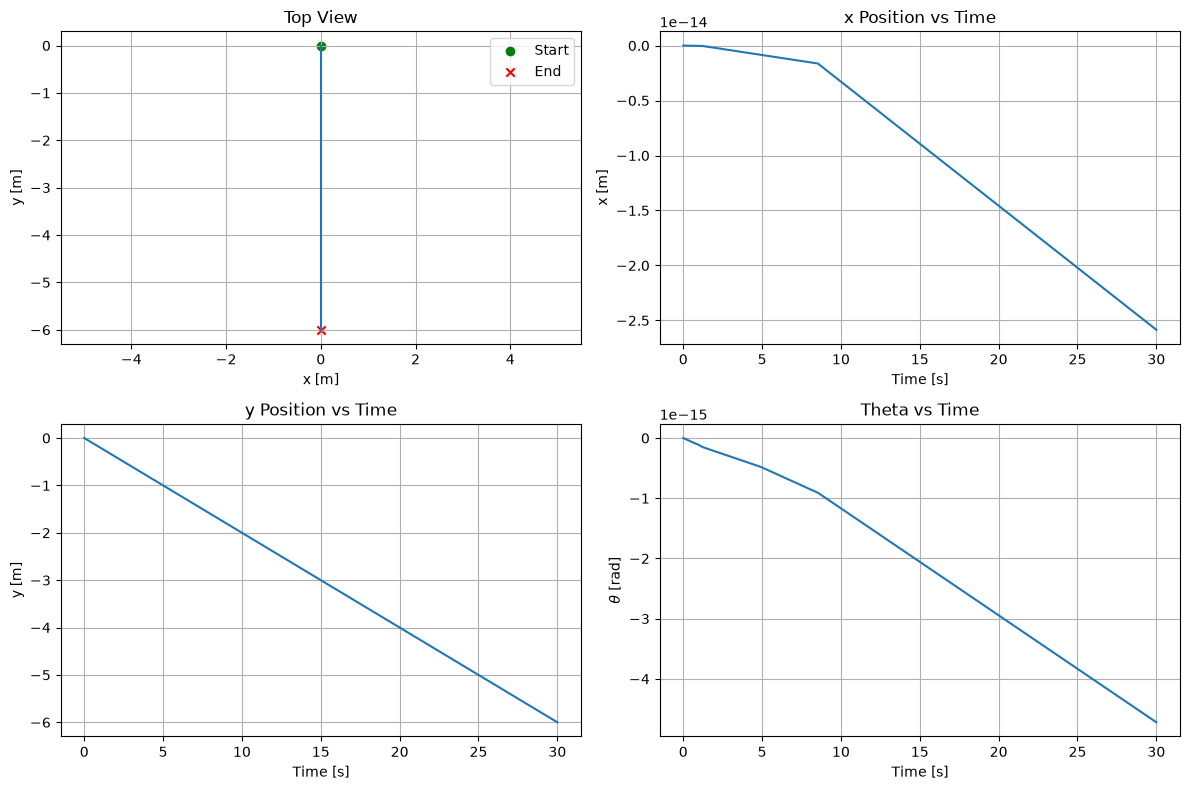

In [3]:
# Calculate the inverse 

wheel_speeds = np.array([u1, u2, u3])
print (wheel_speeds)

## This function computes A^-1*U which gives us the robot motion in terms of x_dot, y_dot, and theta_dot
def robot_motion(state, t):
    x, y, theta = state
    return np.linalg.solve(construct_matrix(theta), wheel_speeds)

## Got to run sim for 30s 
t = np.linspace(0, 30, 1001)
initial_state = [0.0, 0.0, 0.0]  # x, y, theta at t = 0
solution = odeint(robot_motion, initial_state, t) 

x = solution[:, 0]
y = solution[:, 1]
theta = solution[:, 2]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top view
axes[0, 0].plot(x, y)
axes[0, 0].scatter(x[0], y[0], color="green", label="Start")
axes[0, 0].scatter(x[-1], y[-1], color="red", marker="x", label="End")
axes[0, 0].set(title="Top View", xlabel="x [m]", ylabel="y [m]")
axes[0, 0].axis("equal")
axes[0, 0].legend()

# x versus time
axes[0, 1].plot(t, x)
axes[0, 1].set(title="x Position vs Time", xlabel="Time [s]", ylabel="x [m]")

# y versus time
axes[1, 0].plot(t, y)
axes[1, 0].set(title="y Position vs Time", xlabel="Time [s]", ylabel="y [m]")

# Theta versus time
axes[1, 1].plot(t, theta)
axes[1, 1].set(title="Theta vs Time", xlabel="Time [s]", ylabel=r"$\theta$ [rad]")

for ax in axes.flat:
    ax.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
## For the second part, the idea is the same but we know the desired path

## Case 1: 60 degree straight line 
v = 0.1  # m/s - assumed this 
desired_velocity = np.array([
    v * np.cos(np.deg2rad(60)),
    v * np.sin(np.deg2rad(60)),
    0.0
])

## Assuming 0 degrees for the initial orientation of the robot, we can compute the wheel speeds for the straight line motion
u_straight = construct_matrix(0.0) @ desired_velocity ## @ is matrix multiplication (doing A*[x_dot, y_dot, theta_dot]^T)
print(u_straight)

## Case 2: Circular path with radius 1 m 
radius = 1.0  # m
angular_velocity = (2*np.pi)/30  # rad/s --> just applying formula of 2pi/T to get the angular velocity for a 30s period

def desired_velocity_circular(time):
    return np.array([
        -angular_velocity * radius * np.sin(angular_velocity * time),
        angular_velocity * radius * np.cos(angular_velocity * time),
        angular_velocity
    ])

# Assuming the robot starts at the origin and is oriented along the positive x-axis, we can compute the wheel speeds for the circular motion at time t=0
u_circular = construct_matrix(np.pi/2) @ desired_velocity_circular(0.0) ## zero is the initial time 
print("Circular wheel speeds (rad/s):", u_circular)


[ 8.66025404e-01 -8.66025404e-01 -3.55378160e-16]
Circular wheel speeds (rad/s): [ 2.61799388 -0.52359878 -0.52359878]


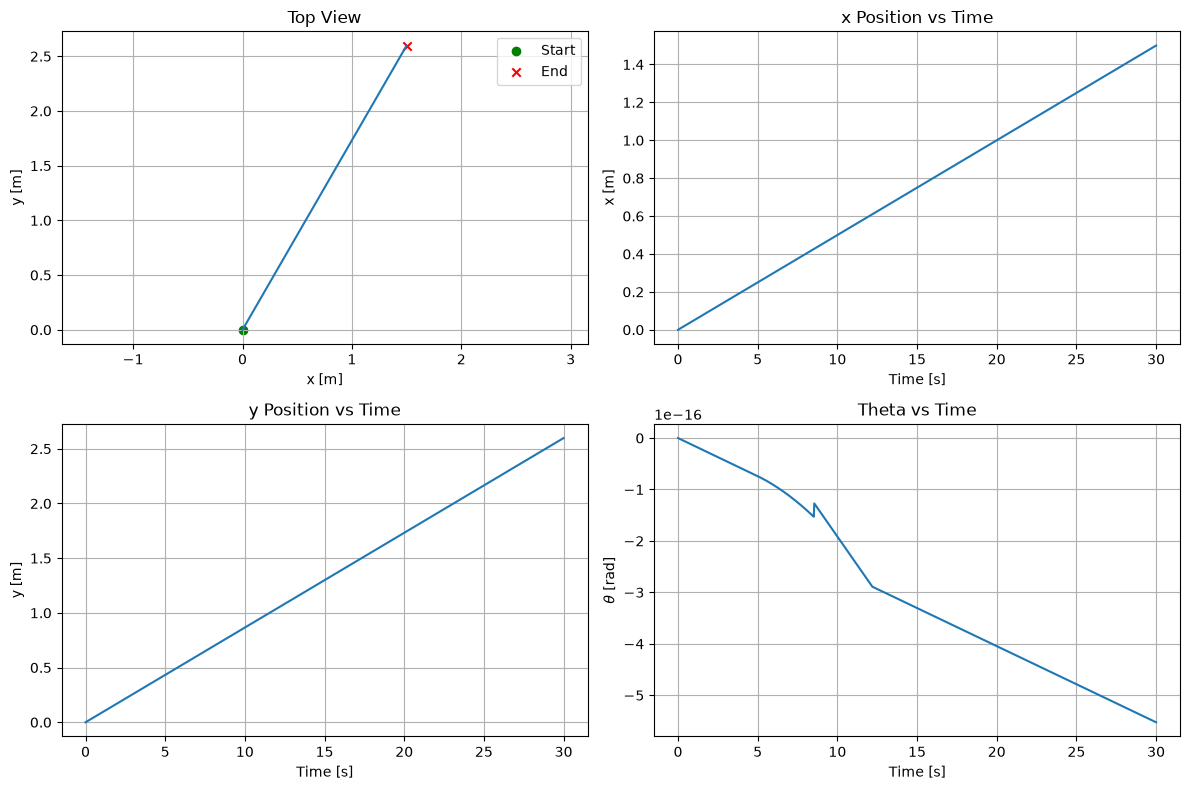

In [8]:
## Actually simulating both cases

## Case 1: Striaght line motion
def robot_motion_straight(state, time):
    x, y, theta = state
    return np.linalg.solve(construct_matrix(theta), u_straight)

t_straight = np.linspace(0, 30, 1001)
initial_state_straight = [0.0, 0.0, 0.0]

solution_straight = odeint(
    robot_motion_straight, initial_state_straight, t_straight
)


x_straight = solution_straight[:, 0]
y_straight = solution_straight[:, 1]
theta_straight = solution_straight[:, 2]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top view
axes[0, 0].plot(x_straight, y_straight)
axes[0, 0].scatter(
    x_straight[0], y_straight[0], color="green", label="Start"
)
axes[0, 0].scatter(
    x_straight[-1], y_straight[-1], color="red", marker="x", label="End"
)
axes[0, 0].set(title="Top View", xlabel="x [m]", ylabel="y [m]")
axes[0, 0].axis("equal")
axes[0, 0].legend()

# x versus time
axes[0, 1].plot(t_straight, x_straight)
axes[0, 1].set(title="x Position vs Time", xlabel="Time [s]", ylabel="x [m]")

# y versus time
axes[1, 0].plot(t_straight, y_straight)
axes[1, 0].set(title="y Position vs Time", xlabel="Time [s]", ylabel="y [m]")

# Theta versus time
axes[1, 1].plot(t_straight, theta_straight)
axes[1, 1].set(title="Theta vs Time", xlabel="Time [s]", ylabel=r"$\theta$ [rad]")

for ax in axes.flat:
    ax.grid(True)

plt.tight_layout()
plt.show()


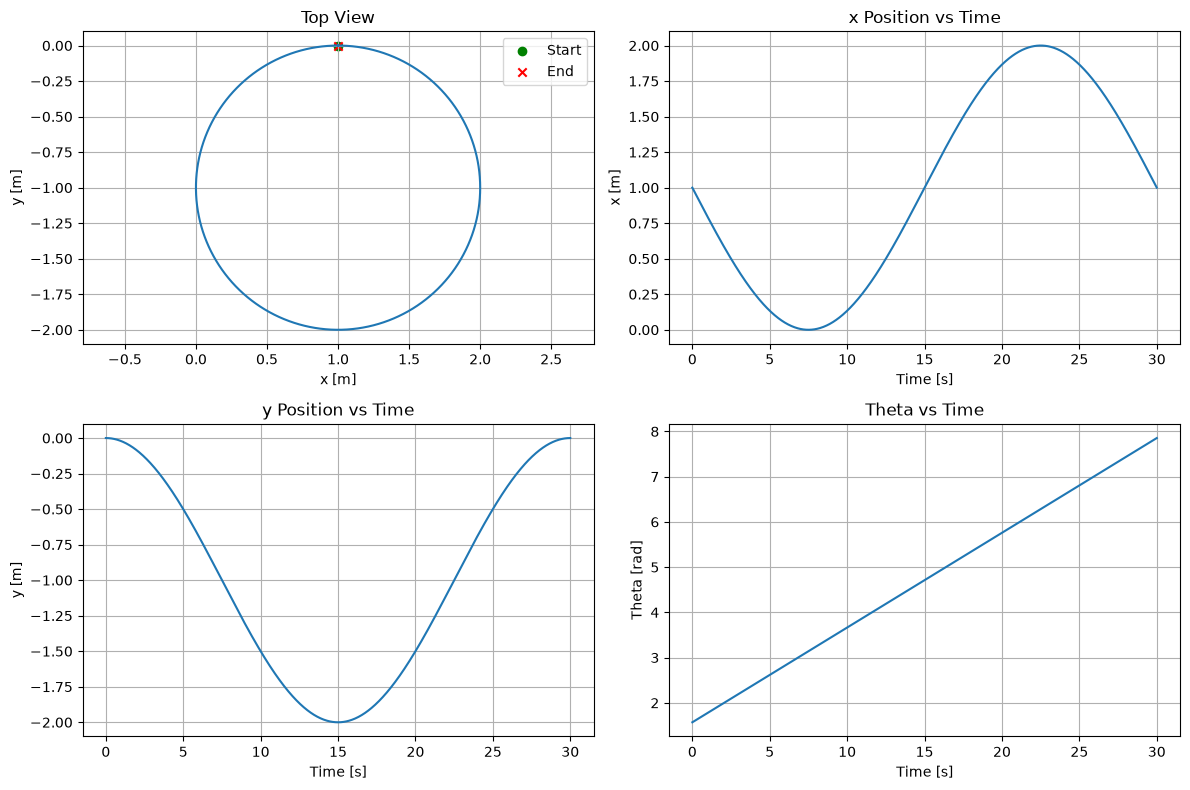

In [9]:

## Case 2: Circular motion
def robot_motion_circular(state, time):
    x, y, theta = state
    return np.linalg.solve(construct_matrix(theta), u_circular)

t_circular = np.linspace(0, 30, 1001)
initial_state_circular = [radius, 0.0, np.pi/2]

solution_circular = odeint(
    robot_motion_circular, initial_state_circular, t_circular
)

x_circular = solution_circular[:, 0]
y_circular = solution_circular[:, 1]
theta_circular = solution_circular[:, 2]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Top view
axes[0, 0].plot(x_circular, y_circular)
axes[0, 0].scatter(
    x_circular[0], y_circular[0], color="green", label="Start"
)
axes[0, 0].scatter(
    x_circular[-1], y_circular[-1], color="red", marker="x", label="End"
)
axes[0, 0].set(title="Top View", xlabel="x [m]", ylabel="y [m]")
axes[0, 0].axis("equal")
axes[0, 0].legend()

# x versus time
axes[0, 1].plot(t_circular, x_circular)
axes[0, 1].set(title="x Position vs Time", xlabel="Time [s]", ylabel="x [m]")

# y versus time
axes[1, 0].plot(t_circular, y_circular)
axes[1, 0].set(title="y Position vs Time", xlabel="Time [s]", ylabel="y [m]")

# Theta versus time
axes[1, 1].plot(t_circular, theta_circular)
axes[1, 1].set(title="Theta vs Time", xlabel="Time [s]", ylabel="Theta [rad]")

for ax in axes.flat:
    ax.grid(True)

plt.tight_layout()
plt.show()